In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Yeh Python ki ek advance data visualization library hai jo khaas taur par statistical charts 
# (jaise histogram, scatter plot, box plot) ko bohot hi professional aur dildash bana deti hai.

In [4]:
# sns.set_theme(...)
# The Magic Switch: Yeh poori notebook ke default graph design ko badal deta hai.
# Isko chalane ke baad aap chahein Matplotlib ka code likhein ya Seaborn ka, aapke saare graphs
# ka background, lines, aur fonts automatic ek modern global style mein dhal jayenge.



# style='whitegrid'
# Whitegrid Style: Iska matlab hai ke aapka chart ab se bilkul saaf-suthra white background ke
# saath aayega, aur uske peeche halki si grey rang ki horizontal aur vertical grid lines khud-ba-khud 
# ban jayengee. Humein alag se plt.grid() likhne ki zaroorat bhi nahi paregi!

sns.set_theme(style='whitegrid')

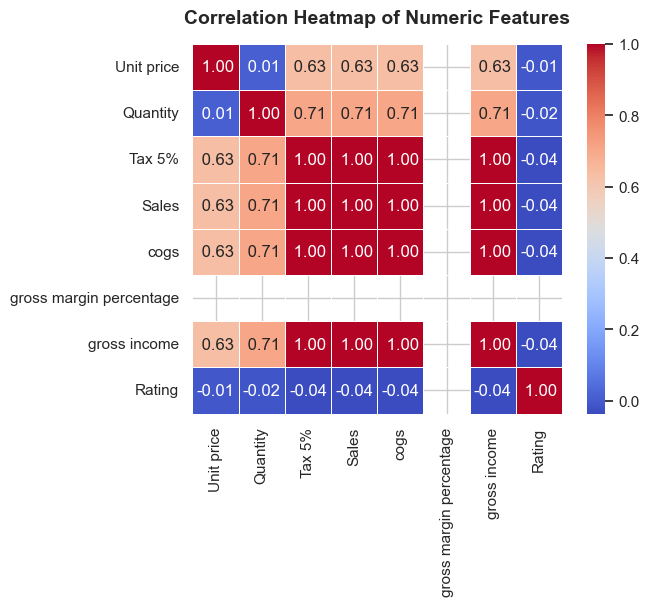

In [5]:
# Build a correlation heatmap of all numeric columns
# corr = df.select_dtypes(include='number').corr() then sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

df = pd.read_csv("SuperMarket Analysis.csv")

# Step 1: Sirf numbers wale columns alag karna aur unka correlation nikaalna


# Python mein correlation (math) sirf numbers par chal sakti hai, text par nahi (jaise Branch ya City par nahi chal sakti).
# Yeh function hamari table mein se sirf un columns ko chunta hai jisme numbers hain (jaise Sales, Quantity, Rating wagera).


# .corr(): Yeh Pandas ka function hai jo sabhi number wale columns ka aapas mein Correlation Coefficient 
# (rishta) nikaalta hai. Yeh har do columns ko check karke unhe $-1$ se $+1$ ke darmiyan ek number de deta hai.
    
corr = df.select_dtypes(include='number').corr()


# sns.heatmap(corr...): Seaborn ka yeh function us correlation ke numbers ko ek rang-bi-rangi (color-coded) 
# grid mein badal deta hai. Ghaur se dekhne ki zaroorat nahi parti, rang dekh kar hi pata chal jata hai rishta kaisa hai.

# annot=True: (Annotation) Agar aap yeh True nahi karenge, toh boxes mein sirf rang nazar aayenge, numbers nahi. 
# True karne se har box ke andar uska asli score (jaise 0.55 ya -0.12) likha hua nazar aayega.


# fmt='.2f': Yeh formatting hai. Iska matlab hai ke box ke andar point ke baad sirf 2 decimals tak number dikhao
# (jaise 0.76543 ki jagah sirf 0.77 dikhao), taake kachra na mache aur saaf dikhe.


# cmap='coolwarm': (Color Map) Yeh is chart ka sabse behtareen rang hai. Isme jo strong positive rishtey hote hain
# woh Tez Laal (Warm/Red) rang ke ho jate hain, aur jo negative rishtey hote hain
# woh Tez Neele (Cool/Blue) rang ke ho jate hain.


sns.heatmap(corr, annot = True, fmt = ' .2f', cmap = 'coolwarm', square = True, linewidths=0.5)

# Step 3: Title lagana
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold', pad=15)

# Image save karna client ke liye
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')

# Display graph
plt.show()




# Aapko top-left se lekar bottom-right tak 1.00 likha hua ek diagonal (tircha) rasta dikha raha hoga.
# Yeh kyun hai? Kyunki har column ka apne aap se rishta hamesha 100% hota hai. Jaise Unit price ka Unit price
# ke saath box 1.00 hai, Quantity ka Quantity ke saath 1.00 hai.


# Aapko beech mein ek bada sa dark red block dikh raha hoga jahan Tax 5%, Sales, cogs, aur gross income 
# aapas mein mil rahe hain, aur sabka score 1.00 likha hai.


# Iska business matlab kya hai? Yeh sab aapas mein poori tarah jure hain! Agar kisi bill ki Sales (paisa) barhegi,
# toh zahir hai us par lagne wala Tax bhi barhegi, uski cogs (cost) bhi barhegi,
# aur company ki gross income bhi barhegi. Yeh 100% lazmi baat hai, isliye yeh poora dabba tez laal hai.



# Ab sabse niche wali row dekhein jo Rating ki hai. Saare dabbe neele hain aur numbers hain: -0.01, -0.02, -0.04.
# Iska business matlab kya hai? Rating ka dukaan ki sales, quantity, ya unit price se koi lena dena nahi hai.
# Aisa nahi hai ke jo customer mehngi cheez (Unit price) khareed raha hai woh achi rating dega, ya jo bohot 
# saara saaman (Quantity) le raha hai woh khush ho kar jayega. Rating har customer apne mizaaj aur store ke
#  mahool ke mutabiq de raha hai, paiso ke mutabiq nahi!



# "Sir, hamara data dikha raha hai ke Sales aur Quantity ka aapas mein strong rishta (0.71) hai, yani customer jitna zyada 
# saaman uthata hai, revenue utni hi tezi se barhti hai. Lekin Customer Rating ka hamari sales ya product ki price se koi 
# talluq nahi hai, iska matlab hai service quality par alag se focus karna parega."


C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_9240\2218297976.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product line', y='Sales', palette='Set2')


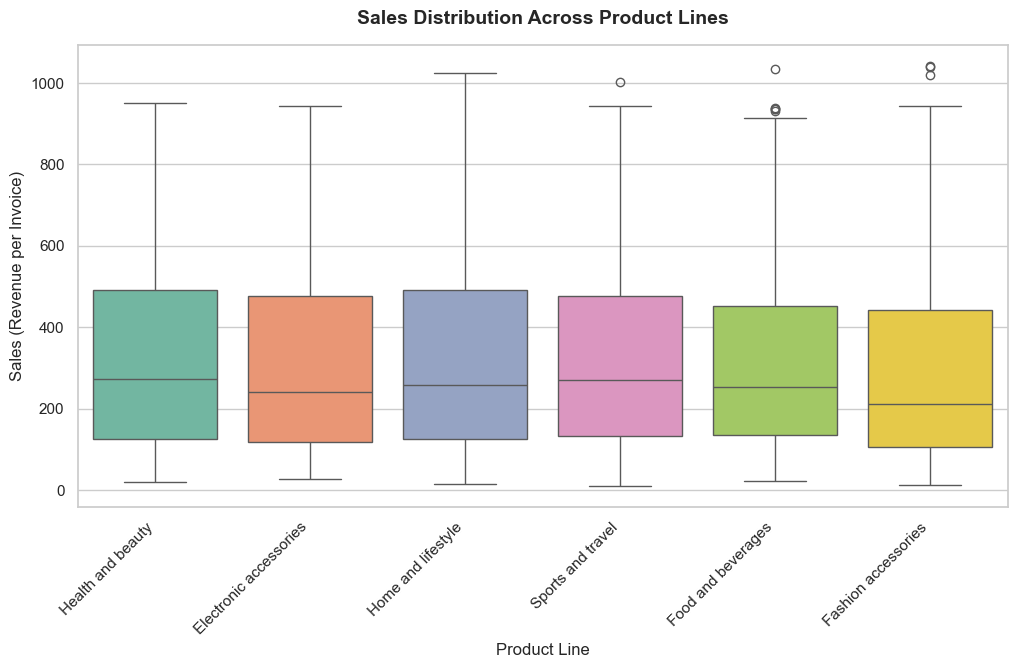

In [7]:
# 2. Boxplot plot karna
plt.figure(figsize=(12, 6)) # Size thoda lamba rakha hai taake product lines ke naam saaf dikhein


# sns.boxplot: Yeh Seaborn ka function hai jo har product line ke liye ek alag dabba (box) khada karega.
# palette='Set2': Yeh Seaborn ke premium rangon ka set hai jo har product line ko ek bohot hi pyara aur soft alag rang de dega.
# rotation=45: Kyunki product lines ke naam bade hote hain (jaise Fashion accessories, Electronic accessories), agar yeh seedhe
# # likhe hon toh aapas mein ghuss jate hain aur parhay nahi jate. 45 likhne se yeh diagonal (tirche) ho jayenge.
# ha='right': (Horizontal Alignment) Iska matlab hai ke text ka aakhri hissa nichli line ke tick ke bilkul neeche 
# aayega, jisse graph ek dam clean dikhta hai.


sns.boxplot(data=df, x='Product line', y='Sales', palette='Set2')

# 3. Sajawat (Title aur Labels)
plt.title('Sales Distribution Across Product Lines', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Line', fontsize=12)
plt.ylabel('Sales (Revenue per Invoice)', fontsize=12)

# 🌟 X-axis ke labels ko 45 degrees ghumana taake naam aapas mein takrayein nahi
plt.xticks(rotation=45, ha='right')

# Image save karna client ke liye
plt.savefig('sales_boxplot.png', dpi=150, bbox_inches='tight')

# Display chart
plt.show()



# Sabse zyada stable sales kiski hain? (Yellow Box)
# Aap sabse aakhri wala yellow dabba dekhein. Iski beech wali line (Median) baaki sabse neeche 
# (lagbhag 200 ke paas) hai. Iska matlab hai ke aam taur par is product line ke bills baaki sabse saste bante hain.



# Sabse bada bill kis category mein bana? (Blue Box)
# Aap teesra neela dabba dekhein (Home and lifestyle ya jo bhi wahan likha hai). Iski upar wali dandi (whisker) 
# sabse upar ja rahi hai, jo lagbhag 1020 ko touch kar rahi hai. Iska matlab hai
# is category mein hamara normal range ka sabse bada bill bana tha.



# Aapko pink, green aur yellow dabbe ke upar akele khre chote chote circles (o) dikh rahe honge.
# Inhe data science mein Outliers kehte hain.
# Business Matlab: Yeh woh normal grahak nahi hain jo aam shopping karte hain. 
#  Yeh woh VIP log hain jinhone achanak routine se hat kar bohot bhari shopping kar li, 
# jiski wajah se unka bill normal range (maximum whisker) se bhi baahar nikal gaya!




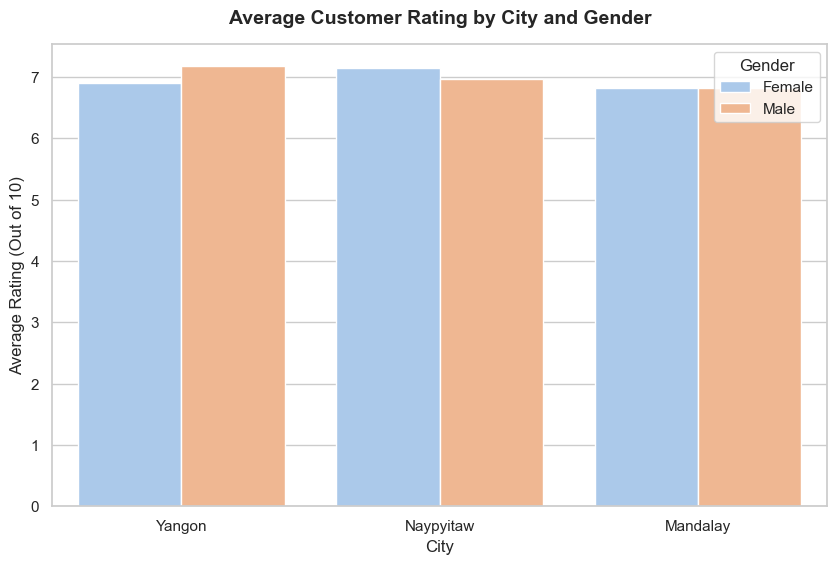

In [8]:
# Build a barplot: average rating by city, colored by gender
# sns.barplot(data=df, x='City', y='Rating', hue='Gender')


# Bhai, yeh graph aapko yeh samajhne mein madad karega ke kis shehar mein kis gender ke log aapke store se zyada khush hain! 
# Jab aap hue='Gender' lagate hain, toh Seaborn automatic har city ke do alag-alag khambey
# (bars) bana dega—ek Males ke liye aur ek Females ke liye.


# 2. Barplot plot karna (Aapke bataye hue parameters ke saath)
plt.figure(figsize=(10, 6))

# ci=None lagane se bars ke upar ki black line (error bar) hat jati hai, jisse chart clean dikhta hai


# sns.barplot: Yeh Seaborn ka function hai jo average (mean) nikalne ke liye use hota hai.
# Matplotlib mein pehle hume khud groupby karke mean nikalna parta tha, lekin Seaborn parde
# ke peeche khud-ba-khud average calculate kar leta hai.


# x='City': $X\text{-axis}$ (neeche) par aapke shehar (jaise Yangon, Mandalay, Naypyitaw) aayenge.
# y='Rating': Bars ki oonchai kis cheez par tay hogi? Customers ki average rating par.



# hue='Gender': hue ka matlab hota hai data ko mazeed rangon mein torna. Is line se Pandas 
# har shehar ke andar ja kar data ko split karega aur Male/Female
# ke alag khambey bana kar unhe alag rang de dega.


# errorbar=None (Ya ci=None)
# Agar aap yeh nahi likhenge, toh har bar ke bilkul top par ek choti si kaali deewar/line
# (Confidence Interval) bani hui aayegi jo statistical uncertainty dikhati hai.
# Client ko dikhane ke liye hum isay None kar dete hain taake graph simple aur saaf dikhe.


# Muwazna (Comparison): Agar kisi shehar (misaal ke taur par Yangon) mein Female ka bar Male
# ke bar se ooncha hai, toh aap owner ko bol sakte hain: "Sir, Yangon mein hamari female customers
# zyada satisfied hain aur unki average rating mardon se behtar hai!"

# Target Marketing: Jis shehar mein jis gender ki rating kam hogi, owner wahan unke mutabiq apni
# service behtar karne ki koshish karega.


sns.barplot(data=df, x='City', y='Rating', hue='Gender', palette='pastel', errorbar=None)

# 3. Sajawat (Title aur Labels)
plt.title('Average Customer Rating by City and Gender', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Rating (Out of 10)', fontsize=12)

# Legend (jo batata hai kaun sa rang kis gender ka hai) uski position set karna
plt.legend(title='Gender', loc='upper right')

# Image save karna client ke liye
plt.savefig('rating_by_city_gender.png', dpi=150, bbox_inches='tight')

# Display chart
plt.show()


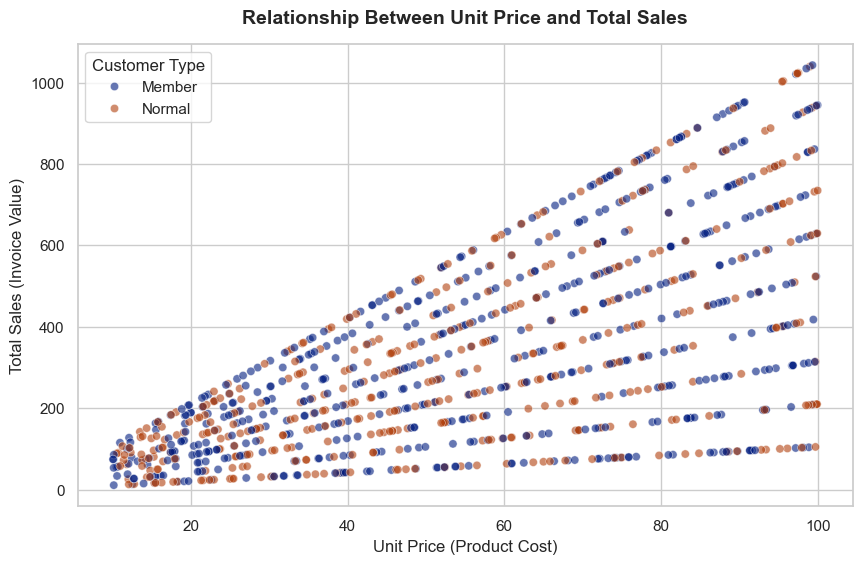

In [9]:

# Build a scatterplot: Unit price vs Sales, colored by Customer type
# sns.scatterplot(data=df, x='Unit price', y='Sales', hue='Customer type', alpha=0.6)


# Abhi tak humne bars aur lines dekhin jo data ko jama (aggregate) karke dikhati hain.
# Lekin Scatter Plot ka kaam bilkul alag hai—yeh aapke dataset ki ek ek row (har single bill) 
# ko graph par ek chote se dot (nukte) ki tarah phenk deta hai. Is se humein do bade numbers 
# (Unit price aur Sales) ke darmiyan ka asli pattern pata chalta hai.


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Unit price', y='Sales', hue='Customer type', alpha=0.6, palette='dark')


# hue='Customer type'
# Yeh Pandas ko bolega ke customers ko unke type ke mutabiq split karo (jaise Member aur Normal). 
# Seaborn automatic Members ke dots ko alag rang de dega aur Normal customers ke dots ko alag rang, 
# taake hum dono ka mukabla kar sakein.



# alpha=0.6
# Alpha (Transparency): Yeh bohot zaroori cheez hai! Agar aapke data mein hazaron dots hain aur woh ek dusre
# ke upar baith jayenge, toh ghanna andhera ho jayega (overplotting). alpha=0.6 karne se saare dots 60% thode 
# transparent (halke glass jaise) ho jate hain. Jahan bohot saare dots aapas mein takrayenge, woh jagah khud-ba-khud
# gehri ho jayegi, jisse asli bheed (density) ka pata chalta hai.




# The Fan Shape Pattern (Pankhe jaisa bikhraav): Aap ghaur karenge ke jab Unit price kam (shuru mein) hogi, 
# toh dots upar nahi ja rahe honge (sales choti hogi). Lekin jaise jaise Unit price barhegi, dots upar ki taraf 
# phailna shuru ho jayenge. Iska matlab hai ke mehangi cheezon par bade bills banne ke chances zyada hote hain
# (jo ke bilkul logical baat hai).



# Customer Type Mukabla: Kya Member wale log sasti cheezein khareed rahe hain ya mehangi? Agar dono rangon ke dots
# poore graph par barabar bikhre hue hain, toh iska matlab hai ke Member ho ya Normal customer, shopping ka 
# mizaaj dono ka bilkul ek jaisa hai!



# 3. Sajawat (Title aur Labels)
plt.title('Relationship Between Unit Price and Total Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Unit Price (Product Cost)', fontsize=12)
plt.ylabel('Total Sales (Invoice Value)', fontsize=12)

# Legend ki setting
plt.legend(title='Customer Type')

# Image save karna client ke liye
plt.savefig('price_vs_sales_scatter.png', dpi=150, bbox_inches='tight')

# Display chart
plt.show()




#{Sales} = {Unit Price} * {Quantity}
# Sabse Neeche Wali Line (Quantity = 1):Apne graph mein bilkul neeche dekhein, jahan se saare dots shuru ho rahe hain.
# Ek bilkul halki dhalan (low slope) wali seedhi line ja rahi hai jo $Y\text{-axis}$ par 100 se neeche neeche hi rehti hai, 
# chahe Unit Price $100$ tak chali jaye.Yeh woh line hai jahan har dot par customer ne sirf 1 item khareeda hai. Isliye agar Unit Price 100 hai, 
# toh Total Sales bhi 100 hai (unka dot $X=100, Y=100$ par laga hua hai).


# Sabse Upar Wali Line (Quantity = Max/10):Ab graph ke sabse upar ka
# kinara dekhein. Jo dots sabse tezi se upar bhaag rahe hain aur aakhir mein $Y\text{-axis}$ par 1000 se bhi upar touch kar rahe hain.Yeh
# sabse unchi tirchi line hai. Yahan har dot par customer ne sabse zyada saaman (jaise 10 quantities) khareeda hai. Isliye jab
# Unit Price $100$ pohnchi, toh $100 \times 10$ mil kar total bill $1000$ se upar nikal gaya!







In [10]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


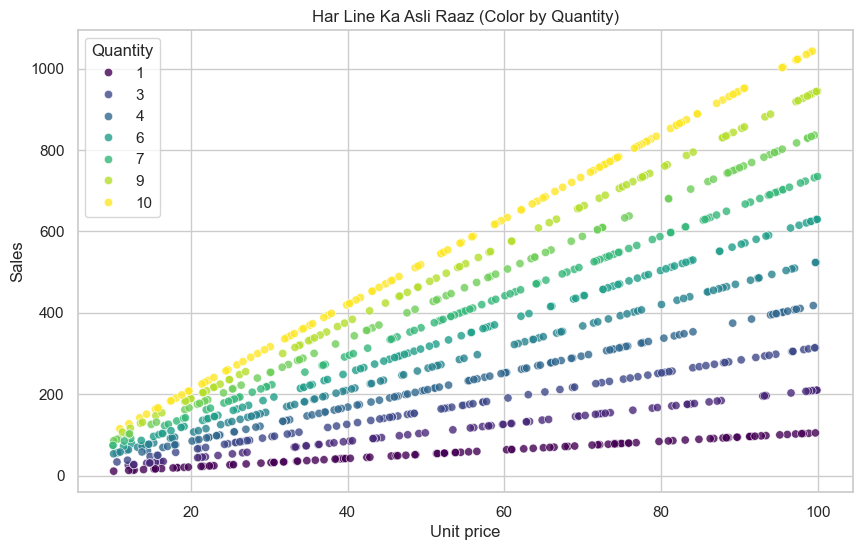

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Unit price', y='Sales', hue='Quantity', palette='viridis', alpha=0.8)
plt.title('Har Line Ka Asli Raaz (Color by Quantity)')
plt.show()